In [1]:
from jax import config, vmap
config.update("jax_enable_x64", True)

import os, re, csv, h5py
import numpy as np
import jax
import jax.numpy as jnp

# =================== CONFIG ===================
MAT_FILES = {
    "FILCOH": [
        "/storage/scratch1/1/bchoi73/filcoh_1e-4.mat",
        "/storage/scratch1/1/bchoi73/filcoh_1e-5.mat",
        "/storage/scratch1/1/bchoi73/filcoh_1e-6.mat",
    ],
    "MATURE": [
        "/storage/scratch1/1/bchoi73/maturevm_1e-4.mat",
        "/storage/scratch1/1/bchoi73/maturevm_1e-5.mat",
        "/storage/scratch1/1/bchoi73/maturevm_1e-6.mat",
    ],
    "CONDENSATE": [
        "/storage/scratch1/1/bchoi73/condensate_1e-4.mat",
        "/storage/scratch1/1/bchoi73/condensate_1e-5.mat",
        "/storage/scratch1/1/bchoi73/condensate_1e-6.mat",
    ],
}

Lx = Ly = 2.0 * jnp.pi                               # periodic box
DELTAS = jnp.geomspace(2*jnp.pi/512, 2*jnp.pi/2, 200)  # Δ sweep (raw Δ saved)
MAX_T = 5                                             # None for all frames
OUTDIR = "out_ratios_enstrophy"
os.makedirs(OUTDIR, exist_ok=True)
# ==============================================


# ---------------- I/O helpers -----------------
def parse_nu_from_filename(path: str) -> float:
    m = re.search(r'_([-+eE0-9\.]+)\.mat$', os.path.basename(path))
    if not m:
        raise ValueError(f"Cannot parse ν from filename: {path}")
    return float(m.group(1))

def load_variable_from_mat(mat_file_path, variable_name):
    """Efficiently load a single variable from a MATLAB v7.3 .mat file."""
    try:
        with h5py.File(mat_file_path, 'r') as f:
            if variable_name in f:
                return np.array(f[variable_name])
            else:
                raise KeyError(f"Variable '{variable_name}' not found in {mat_file_path}")
    except Exception as e:
        raise RuntimeError(f"Error loading .mat file {mat_file_path}: {e}")

def load_velocity_uv(path: str, max_t: int | None = MAX_T) -> jnp.ndarray:
    """
    Return velocity array u with shape (Nx, Ny, 2, T), dtype float64, from 's'.
    Supports shapes: (T,2,Nx,Ny) OR (2,Nx,Ny,T). Swaps [0,1] -> (V,U) if needed.
    """
    s_np = load_variable_from_mat(path, "s")
    s = jnp.asarray(s_np)

    if s.ndim != 4:
        raise ValueError(f"Unsupported 's' shape: {s.shape}")

    # Handle common layouts
    if s.shape[1] == 2:            # (T,2,Nx,Ny)
        T, C, Nx, Ny = s.shape
        U = s[:, 0, :, :]          # U is channel 1
        V = s[:, 1, :, :]          # V is channel 0
    elif s.shape[0] == 2:          # (2,Nx,Ny,T)
        C, Nx, Ny, T = s.shape
        U = s[0, :, :, :].transpose(3, 0, 1)  # (T,Nx,Ny)
        V = s[1, :, :, :].transpose(3, 0, 1)
    else:
        raise ValueError(f"Unknown 's' layout: {s.shape}")

    if max_t is not None:
        T = min(T, int(max_t))
        U, V = U[:T, :, :], V[:T, :, :]

    # (Nx,Ny,T)
    U = jnp.transpose(U, (1, 2, 0))
    V = jnp.transpose(V, (1, 2, 0))

    # (Nx,Ny,2,T)
    u = jnp.stack([U, V], axis=2).astype(jnp.float64)
    return u


# ----------------- Filters & Derivatives -----------------
def gaussian_filter_fft(field: jnp.ndarray, Delta: float, Lx: float, Ly: float) -> jnp.ndarray:
    """
    Gaussian filter with kernel  Ĝ(k) = exp(-(k^2 Δ^2)/24)
    Works on (Nx,Ny), (Nx,Ny,C), or (Nx,Ny,C,T).
    """
    if field.ndim not in (2, 3, 4):
        raise ValueError("field must have 2D, 3D, or 4D shape")

    Nx, Ny = field.shape[:2]
    dx, dy = Lx / Nx, Ly / Ny
    kx = jnp.fft.fftfreq(Nx, d=dx) * 2.0 * jnp.pi
    ky = jnp.fft.fftfreq(Ny, d=dy) * 2.0 * jnp.pi
    kx_grid, ky_grid = jnp.meshgrid(kx, ky, indexing='ij')  # (Nx,Ny)
    k2 = kx_grid**2 + ky_grid**2
    Ghat = jnp.exp(-k2 * (Delta**2) / 24.0).astype(field.dtype)

    def filt2(x2d):
        F = jnp.fft.fft2(x2d, axes=(-2, -1))
        y = jnp.fft.ifft2(F * Ghat, axes=(-2, -1))
        return y.real.astype(field.dtype) if jnp.isrealobj(x2d) else y.astype(field.dtype)

    if field.ndim == 2:
        return filt2(field)
    elif field.ndim == 3:  # (Nx,Ny,C)
        return vmap(filt2, in_axes=2, out_axes=2)(field)
    else:  # (Nx,Ny,C,T)
        def filt3(x3d):  # (Nx,Ny,C)
            return vmap(filt2, in_axes=2, out_axes=2)(x3d)
        return vmap(filt3, in_axes=3, out_axes=3)(field)

def filtered_gradients(ux_f: jnp.ndarray, uy_f: jnp.ndarray, Lx: float, Ly: float):
    """
    Compute derivatives via spectral differentiation on filtered fields.
    Returns Sxx, Sxy, Syy (same shapes as inputs).
    """
    Nx, Ny = ux_f.shape
    dx, dy = Lx / Nx, Ly / Ny
    kx = jnp.fft.fftfreq(Nx, d=dx) * 2.0 * jnp.pi
    ky = jnp.fft.fftfreq(Ny, d=dy) * 2.0 * jnp.pi
    kx_grid, ky_grid = jnp.meshgrid(kx, ky, indexing='ij')

    Ux = jnp.fft.fft2(ux_f)
    Uy = jnp.fft.fft2(uy_f)

    ux_x = jnp.fft.ifft2(1j * kx_grid * Ux).real
    ux_y = jnp.fft.ifft2(1j * ky_grid * Ux).real
    uy_x = jnp.fft.ifft2(1j * kx_grid * Uy).real
    uy_y = jnp.fft.ifft2(1j * ky_grid * Uy).real

    Sxx = ux_x
    Syy = uy_y
    Sxy = 0.5 * (ux_y + uy_x)
    return Sxx, Sxy, Syy


# ----------------- Energetics -----------------
def eps_nu_sum_from_S(Sxx: jnp.ndarray, Sxy: jnp.ndarray, Syy: jnp.ndarray, nu: float) -> float:
    """
    Sum over space (caller sums over time).
    NOTE: returns POSITIVE-definite viscous dissipation  ε_ν = 2ν (S:S).
    """
    S2 = Sxx*Sxx + 2.0*Sxy*Sxy + Syy*Syy
    return float(2.0 * nu * jnp.sum(S2))  # positive

def sgs_Pi_signed_sum(ux: jnp.ndarray, uy: jnp.ndarray,
                      Delta: float, Lx: float, Ly: float,
                      Sxx: jnp.ndarray, Sxy: jnp.ndarray, Syy: jnp.ndarray) -> float:
    """
    Signed SGS energy transfer sum over space:
      Π = - [ τ_xx Sxx + 2 τ_xy Sxy + τ_yy Syy ],
      with τ = overline(u u) - ū ū (Gaussian filter at Δ).
    """
    ux_f = gaussian_filter_fft(ux, Delta, Lx, Ly)
    uy_f = gaussian_filter_fft(uy, Delta, Lx, Ly)
    txx = gaussian_filter_fft(ux*ux, Delta, Lx, Ly) - ux_f*ux_f
    txy = gaussian_filter_fft(ux*uy, Delta, Lx, Ly) - ux_f*uy_f
    tyy = gaussian_filter_fft(uy*uy, Delta, Lx, Ly) - uy_f*uy_f
    Pi = -(txx*Sxx + 2.0*txy*Sxy + tyy*Syy)
    return float(jnp.sum(Pi))


# ------------- Core per-file routine -------------
def process_one_file(path: str, family: str):
    nu = parse_nu_from_filename(path)
    Re = 1.0 / nu
    dataset = os.path.splitext(os.path.basename(path))[0]
    print(f"\n[{family}] {dataset}   nu={nu:g}  Re≈{Re:.0e}")

    # Load velocity
    u = load_velocity_uv(path)               # (Nx,Ny,2,T)
    Nx, Ny, _, T = u.shape

    # Per-dataset Δ–R rows (for .txt) and per-Δ detailed rows (for CSV)
    rows_txt = []
    rows_csv = []

    area = float(Nx * Ny)

    # Sweep Δ
    for Delta in np.asarray(DELTAS):   # iterate with Python floats
        Delta = float(Delta)

        Pi_sum_all = 0.0
        eps_sum_all = 0.0

        # accumulators for ⟨Sij⟩ and ⟨S^2⟩ (space–time means at this Δ)
        Sxx_sum = 0.0
        Sxy_sum = 0.0
        Syy_sum = 0.0
        S2_sum  = 0.0

        for t in range(int(T)):
            ux = u[:, :, 0, t]
            uy = u[:, :, 1, t]

            # Filter u at Δ, then gradients on filtered u
            ux_f = gaussian_filter_fft(ux, Delta, float(Lx), float(Ly))
            uy_f = gaussian_filter_fft(uy, Delta, float(Lx), float(Ly))
            Sxx, Sxy, Syy = filtered_gradients(ux_f, uy_f, float(Lx), float(Ly))

            # Space sums for energetics
            Pi_sum_all  += sgs_Pi_signed_sum(ux, uy, Delta, float(Lx), float(Ly), Sxx, Sxy, Syy)
            eps_sum_all += eps_nu_sum_from_S(Sxx, Sxy, Syy, nu)

            # Accumulate space sums for ⟨Sij⟩, ⟨S^2⟩
            S2 = Sxx*Sxx + 2.0*Sxy*Sxy + Syy*Syy

            S2_sum  += float(jnp.sum(S2))
        mean_S2  = jnp.mean(S2_sum)

        # Ratio (signed SGS transfer / viscous dissipation), both positive denominator
        R_signed = Pi_sum_all / (eps_sum_all + 1e-300)

        rows_txt.append([Delta, R_signed, mean_S2])

        rows_csv.append([
            family, dataset, f"{Re:.0e}", f"{nu:.6g}",
            int(Nx), int(Ny), int(T),
            float(Delta), float(R_signed), float(Pi_sum_all), float(eps_sum_all),
            float(mean_S2),
        ])

        print(f"  Δ={Delta:.6f}  R_signed={R_signed:.3e} ")

    # Save per-dataset Δ–R (+ ⟨Sij⟩) file
    txt_path = os.path.join(OUTDIR, f"{dataset}_Delta_R_signed.txt")
    header = "Delta  Ratio_signed mean_S2"
    np.savetxt(txt_path, np.asarray(rows_txt), fmt="%.8e", header=header)
    return rows_csv


def main():
    all_rows = []
    for fam, files in MAT_FILES.items():
        for p in files:
            if not os.path.exists(p):
                print(f"[WARN] missing: {p}")
                continue
            try:
                all_rows += process_one_file(p, fam)
            except Exception as e:
                print(f"[ERROR] {p}: {e}")

    # Write consolidated CSV (now includes nu and ⟨Sij⟩ columns)
    csv_path = os.path.join(OUTDIR, "ratios_signed_all.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow([
            "family","dataset","Re","nu",
            "Nx","Ny","Nt","Delta","Ratio_signed","Pi_signed_sum","eps_nu_sum",
            "mean_S2"
        ])
        w.writerows(all_rows)
    print(f"\n[OK] Wrote {csv_path}")
    print(f"[OK] Per-dataset Δ–R files in: {OUTDIR}/")

if __name__ == "__main__":
    main()


[FILCOH] filcoh_1e-4   nu=0.0001  Re≈1e+04
  Δ=0.012272  R_signed=-5.439e-05 
  Δ=0.012619  R_signed=-6.070e-05 
  Δ=0.012975  R_signed=-6.773e-05 
  Δ=0.013342  R_signed=-7.558e-05 
  Δ=0.013719  R_signed=-8.432e-05 
  Δ=0.014106  R_signed=-9.407e-05 
  Δ=0.014505  R_signed=-1.049e-04 
  Δ=0.014915  R_signed=-1.170e-04 
  Δ=0.015336  R_signed=-1.305e-04 
  Δ=0.015770  R_signed=-1.455e-04 
  Δ=0.016215  R_signed=-1.623e-04 
  Δ=0.016674  R_signed=-1.809e-04 
  Δ=0.017145  R_signed=-2.016e-04 
  Δ=0.017629  R_signed=-2.247e-04 
  Δ=0.018127  R_signed=-2.503e-04 
  Δ=0.018640  R_signed=-2.789e-04 
  Δ=0.019166  R_signed=-3.106e-04 
  Δ=0.019708  R_signed=-3.459e-04 
  Δ=0.020265  R_signed=-3.851e-04 
  Δ=0.020837  R_signed=-4.287e-04 
  Δ=0.021426  R_signed=-4.771e-04 
  Δ=0.022032  R_signed=-5.309e-04 
  Δ=0.022654  R_signed=-5.906e-04 
  Δ=0.023294  R_signed=-6.568e-04 
  Δ=0.023953  R_signed=-7.303e-04 
  Δ=0.024629  R_signed=-8.118e-04 
  Δ=0.025325  R_signed=-9.021e-04 
  Δ=0.02604

  Δ=0.029934  R_signed=-2.848e-02 
  Δ=0.030780  R_signed=-3.138e-02 
  Δ=0.031650  R_signed=-3.456e-02 
  Δ=0.032544  R_signed=-3.804e-02 
  Δ=0.033464  R_signed=-4.185e-02 
  Δ=0.034409  R_signed=-4.601e-02 
  Δ=0.035381  R_signed=-5.057e-02 
  Δ=0.036381  R_signed=-5.555e-02 
  Δ=0.037409  R_signed=-6.099e-02 
  Δ=0.038466  R_signed=-6.693e-02 
  Δ=0.039553  R_signed=-7.341e-02 
  Δ=0.040671  R_signed=-8.047e-02 
  Δ=0.041820  R_signed=-8.816e-02 
  Δ=0.043002  R_signed=-9.653e-02 
  Δ=0.044217  R_signed=-1.056e-01 
  Δ=0.045466  R_signed=-1.155e-01 
  Δ=0.046751  R_signed=-1.263e-01 
  Δ=0.048072  R_signed=-1.380e-01 
  Δ=0.049431  R_signed=-1.507e-01 
  Δ=0.050827  R_signed=-1.644e-01 
  Δ=0.052264  R_signed=-1.793e-01 
  Δ=0.053740  R_signed=-1.954e-01 
  Δ=0.055259  R_signed=-2.129e-01 
  Δ=0.056820  R_signed=-2.318e-01 
  Δ=0.058426  R_signed=-2.521e-01 
  Δ=0.060077  R_signed=-2.742e-01 
  Δ=0.061774  R_signed=-2.979e-01 
  Δ=0.063520  R_signed=-3.236e-01 
  Δ=0.065315  R_sign

  Δ=0.077201  R_signed=-5.960e+00 
  Δ=0.079382  R_signed=-6.433e+00 
  Δ=0.081626  R_signed=-6.939e+00 
  Δ=0.083932  R_signed=-7.480e+00 
  Δ=0.086304  R_signed=-8.060e+00 
  Δ=0.088742  R_signed=-8.679e+00 
  Δ=0.091250  R_signed=-9.340e+00 
  Δ=0.093828  R_signed=-1.005e+01 
  Δ=0.096480  R_signed=-1.080e+01 
  Δ=0.099206  R_signed=-1.160e+01 
  Δ=0.102009  R_signed=-1.246e+01 
  Δ=0.104892  R_signed=-1.337e+01 
  Δ=0.107856  R_signed=-1.435e+01 
  Δ=0.110903  R_signed=-1.538e+01 
  Δ=0.114037  R_signed=-1.648e+01 
  Δ=0.117260  R_signed=-1.765e+01 
  Δ=0.120573  R_signed=-1.890e+01 
  Δ=0.123980  R_signed=-2.022e+01 
  Δ=0.127483  R_signed=-2.162e+01 
  Δ=0.131086  R_signed=-2.311e+01 
  Δ=0.134790  R_signed=-2.469e+01 
  Δ=0.138599  R_signed=-2.637e+01 
  Δ=0.142515  R_signed=-2.814e+01 
  Δ=0.146542  R_signed=-3.002e+01 
  Δ=0.150683  R_signed=-3.201e+01 
  Δ=0.154941  R_signed=-3.412e+01 
  Δ=0.159319  R_signed=-3.634e+01 
  Δ=0.163821  R_signed=-3.870e+01 
  Δ=0.168450  R_sign

  Δ=0.199104  R_signed=-6.074e-02 
  Δ=0.204730  R_signed=-6.521e-02 
  Δ=0.210516  R_signed=-7.002e-02 
  Δ=0.216464  R_signed=-7.518e-02 
  Δ=0.222581  R_signed=-8.073e-02 
  Δ=0.228870  R_signed=-8.669e-02 
  Δ=0.235337  R_signed=-9.310e-02 
  Δ=0.241987  R_signed=-9.999e-02 
  Δ=0.248825  R_signed=-1.074e-01 
  Δ=0.255856  R_signed=-1.154e-01 
  Δ=0.263086  R_signed=-1.240e-01 
  Δ=0.270520  R_signed=-1.332e-01 
  Δ=0.278164  R_signed=-1.432e-01 
  Δ=0.286024  R_signed=-1.540e-01 
  Δ=0.294107  R_signed=-1.656e-01 
  Δ=0.302417  R_signed=-1.781e-01 
  Δ=0.310963  R_signed=-1.916e-01 
  Δ=0.319749  R_signed=-2.061e-01 
  Δ=0.328785  R_signed=-2.218e-01 
  Δ=0.338075  R_signed=-2.388e-01 
  Δ=0.347628  R_signed=-2.571e-01 
  Δ=0.357451  R_signed=-2.768e-01 
  Δ=0.367552  R_signed=-2.982e-01 
  Δ=0.377938  R_signed=-3.212e-01 
  Δ=0.388617  R_signed=-3.461e-01 
  Δ=0.399598  R_signed=-3.730e-01 
  Δ=0.410890  R_signed=-4.020e-01 
  Δ=0.422500  R_signed=-4.334e-01 
  Δ=0.434439  R_sign

  Δ=0.542928  R_signed=-8.608e+00 
  Δ=0.558270  R_signed=-9.277e+00 
  Δ=0.574045  R_signed=-9.998e+00 
  Δ=0.590265  R_signed=-1.077e+01 
  Δ=0.606945  R_signed=-1.161e+01 
  Δ=0.624095  R_signed=-1.250e+01 
  Δ=0.641730  R_signed=-1.346e+01 
  Δ=0.659864  R_signed=-1.449e+01 
  Δ=0.678509  R_signed=-1.560e+01 
  Δ=0.697682  R_signed=-1.678e+01 
  Δ=0.717397  R_signed=-1.804e+01 
  Δ=0.737668  R_signed=-1.938e+01 
  Δ=0.758513  R_signed=-2.081e+01 
  Δ=0.779946  R_signed=-2.232e+01 
  Δ=0.801985  R_signed=-2.392e+01 
  Δ=0.824647  R_signed=-2.561e+01 
  Δ=0.847949  R_signed=-2.739e+01 
  Δ=0.871909  R_signed=-2.926e+01 
  Δ=0.896547  R_signed=-3.120e+01 
  Δ=0.921881  R_signed=-3.322e+01 
  Δ=0.947930  R_signed=-3.531e+01 
  Δ=0.974716  R_signed=-3.746e+01 
  Δ=1.002259  R_signed=-3.965e+01 
  Δ=1.030580  R_signed=-4.187e+01 
  Δ=1.059701  R_signed=-4.409e+01 
  Δ=1.089645  R_signed=-4.630e+01 
  Δ=1.120435  R_signed=-4.847e+01 
  Δ=1.152095  R_signed=-5.056e+01 
  Δ=1.184650  R_sign

  Δ=1.400233  R_signed=-5.940e+02 
  Δ=1.439800  R_signed=-5.919e+02 
  Δ=1.480484  R_signed=-5.843e+02 
  Δ=1.522318  R_signed=-5.703e+02 
  Δ=1.565335  R_signed=-5.492e+02 
  Δ=1.609566  R_signed=-5.203e+02 
  Δ=1.655048  R_signed=-4.829e+02 
  Δ=1.701815  R_signed=-4.364e+02 
  Δ=1.749903  R_signed=-3.800e+02 
  Δ=1.799350  R_signed=-3.133e+02 
  Δ=1.850195  R_signed=-2.357e+02 
  Δ=1.902476  R_signed=-1.470e+02 
  Δ=1.956234  R_signed=-4.685e+01 
  Δ=2.011512  R_signed=6.473e+01 
  Δ=2.068351  R_signed=1.876e+02 
  Δ=2.126797  R_signed=3.216e+02 
  Δ=2.186894  R_signed=4.661e+02 
  Δ=2.248689  R_signed=6.204e+02 
  Δ=2.312230  R_signed=7.838e+02 
  Δ=2.377567  R_signed=9.551e+02 
  Δ=2.444750  R_signed=1.133e+03 
  Δ=2.513832  R_signed=1.316e+03 
  Δ=2.584865  R_signed=1.504e+03 
  Δ=2.657906  R_signed=1.693e+03 
  Δ=2.733011  R_signed=1.884e+03 
  Δ=2.810238  R_signed=2.074e+03 
  Δ=2.889647  R_signed=2.263e+03 
  Δ=2.971300  R_signed=2.448e+03 
  Δ=3.055260  R_signed=2.629e+03 
 

  Δ=0.013719  R_signed=-1.375e-05 
  Δ=0.014106  R_signed=-1.502e-05 
  Δ=0.014505  R_signed=-1.641e-05 
  Δ=0.014915  R_signed=-1.793e-05 
  Δ=0.015336  R_signed=-1.958e-05 
  Δ=0.015770  R_signed=-2.138e-05 
  Δ=0.016215  R_signed=-2.334e-05 
  Δ=0.016674  R_signed=-2.549e-05 
  Δ=0.017145  R_signed=-2.783e-05 
  Δ=0.017629  R_signed=-3.038e-05 
  Δ=0.018127  R_signed=-3.316e-05 
  Δ=0.018640  R_signed=-3.620e-05 
  Δ=0.019166  R_signed=-3.952e-05 
  Δ=0.019708  R_signed=-4.313e-05 
  Δ=0.020265  R_signed=-4.708e-05 
  Δ=0.020837  R_signed=-5.138e-05 
  Δ=0.021426  R_signed=-5.606e-05 
  Δ=0.022032  R_signed=-6.117e-05 
  Δ=0.022654  R_signed=-6.674e-05 
  Δ=0.023294  R_signed=-7.281e-05 
  Δ=0.023953  R_signed=-7.941e-05 
  Δ=0.024629  R_signed=-8.659e-05 
  Δ=0.025325  R_signed=-9.441e-05 
  Δ=0.026041  R_signed=-1.029e-04 
  Δ=0.026777  R_signed=-1.121e-04 
  Δ=0.027533  R_signed=-1.222e-04 
  Δ=0.028311  R_signed=-1.331e-04 
  Δ=0.029111  R_signed=-1.449e-04 
  Δ=0.029934  R_sign

  Δ=0.035381  R_signed=-2.549e-03 
  Δ=0.036381  R_signed=-2.756e-03 
  Δ=0.037409  R_signed=-2.979e-03 
  Δ=0.038466  R_signed=-3.218e-03 
  Δ=0.039553  R_signed=-3.474e-03 
  Δ=0.040671  R_signed=-3.747e-03 
  Δ=0.041820  R_signed=-4.040e-03 
  Δ=0.043002  R_signed=-4.352e-03 
  Δ=0.044217  R_signed=-4.684e-03 
  Δ=0.045466  R_signed=-5.039e-03 
  Δ=0.046751  R_signed=-5.416e-03 
  Δ=0.048072  R_signed=-5.818e-03 
  Δ=0.049431  R_signed=-6.245e-03 
  Δ=0.050827  R_signed=-6.698e-03 
  Δ=0.052264  R_signed=-7.179e-03 
  Δ=0.053740  R_signed=-7.689e-03 
  Δ=0.055259  R_signed=-8.230e-03 
  Δ=0.056820  R_signed=-8.803e-03 
  Δ=0.058426  R_signed=-9.409e-03 
  Δ=0.060077  R_signed=-1.005e-02 
  Δ=0.061774  R_signed=-1.073e-02 
  Δ=0.063520  R_signed=-1.145e-02 
  Δ=0.065315  R_signed=-1.221e-02 
  Δ=0.067161  R_signed=-1.301e-02 
  Δ=0.069058  R_signed=-1.385e-02 
  Δ=0.071010  R_signed=-1.474e-02 
  Δ=0.073016  R_signed=-1.569e-02 
  Δ=0.075079  R_signed=-1.668e-02 
  Δ=0.077201  R_sign


[Diagnostics] surviving points per family:
             n_datasets  n_points
family_norm                      
CONDENSATE            3       600
FILCOH                3       600
MATURE                3       600


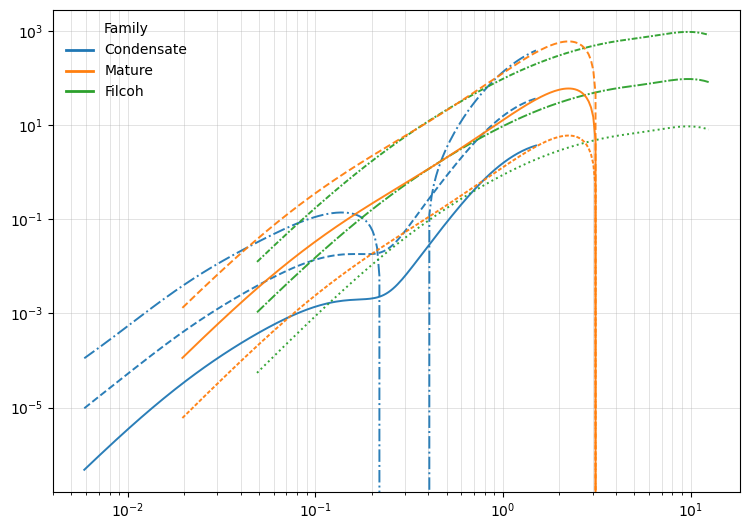

In [12]:
# ===== Debug + lines-only plot (fixed & reproducible) =====
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------- CONFIG ----------------
OUTDIR = "out_ratios_enstrophy"
CSV_PATH = os.path.join(OUTDIR, "ratios_signed_all.csv")

# Plot controls
USE_LOG_X = True
USE_LOG_Y = True
PLOT_MINUS_Y = True          # plot -y so "sink" is positive; set False to plot y directly
SAVE_FIG = False
FIG_PATH = os.path.join(OUTDIR, "plot_lines_only_scaled.png")

# Family length scales L_fam (adjust if your convention changes)
two_pi = 2.0 * np.pi
L_FAM = {
    "CONDENSATE": two_pi / 3.0,
    "MATURE":     two_pi / 10.0,
    "FILCOH":     two_pi / 25.0,
}

# Colors per family
FAM_COLOR = {"CONDENSATE": "C0", "MATURE": "C1", "FILCOH": "C2"}

# Linestyles palette (enough variety; deterministic mapping provided below)
LINESTYLES = ["-", "--", "-.", ":", (0, (5, 1, 1, 1)), (0, (3, 1, 1, 1)), (0, (2, 1))]

# ------------- LOAD -------------
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df_out = pd.read_csv(CSV_PATH)

def norm_fam(s: str) -> str:
    return str(s).strip().upper()

# Normalize labels
df_out["family_norm"] = df_out["family"].map(norm_fam)

# Coerce numeric columns
for c in ["nu", "Delta", "Ratio_signed", "mean_S2"]:
    if c in df_out.columns:
        df_out[c] = pd.to_numeric(df_out[c], errors="coerce")
    else:
        raise KeyError(f"Required column '{c}' not found in {CSV_PATH}")

# Map family -> L_fam (NaN if unknown family)
L_vals = df_out["family_norm"].map(L_FAM).astype(float).to_numpy()
S_mean = np.sqrt(np.clip(df_out["mean_S2"].to_numpy(dtype=float), 0.0, None))
nu_vals = df_out["nu"].to_numpy(dtype=float)

Delta = df_out["Delta"].to_numpy(dtype=float)
Ratio = df_out["Ratio_signed"].to_numpy(dtype=float)

# ------------- NON-DIMENSIONALIZATION -------------
# x = (Δ / L_fam)^4
# y = Ratio_signed / (S_rms * L_fam^2 / ν)
# (Use ** for exponentiation; ^ would be bitwise XOR)

# Denominator: S_rms * L_fam^2 / ν ; guard against non-positive or NaN
den = np.where(
    (S_mean > 0) & np.isfinite(S_mean) &
    (L_vals > 0) & np.isfinite(L_vals) &
    (nu_vals > 0) & np.isfinite(nu_vals),
    S_mean * (L_vals ** 2) / nu_vals,
    np.nan,
)
x = (Delta / L_vals) 
y = Ratio

df_out["x_scaled"] = x
df_out["y_scaled"] = y

# ------------- MASKS & DIAGNOSTICS -------------
m_xpos = np.isfinite(x) & (x > 0)
m_yfin = np.isfinite(y)
m_nu   = np.isfinite(nu_vals) & (nu_vals > 0)
m_s2   = np.isfinite(df_out["mean_S2"].to_numpy(dtype=float)) & (df_out["mean_S2"].to_numpy(dtype=float) >= 0)
m_L    = np.isfinite(L_vals) & (L_vals > 0)  # drop unknown families

m_all = m_xpos & m_yfin & m_nu & m_s2 & m_L
df_plot = df_out.loc[m_all].copy()

print("\n[Diagnostics] surviving points per family:")
print(
    df_plot.groupby("family_norm")["dataset"]
    .agg(n_datasets="nunique", n_points="count")
)

def report_drops(mask, reason):
    dropped = df_out.loc[~mask, ["family_norm", "dataset"]].copy()
    if len(dropped):
        print(f"\n[Drop reason] {reason}: {len(dropped)} rows")
        try:
            print(dropped.groupby("family_norm").size())
        except Exception:
            pass

report_drops(m_L,   "unknown family (no L_fam) or invalid L_fam")
report_drops(m_nu,  "nu is NaN/<=0")
report_drops(m_s2,  "mean_S2 is NaN/<0")
report_drops(m_yfin,"y (scaled ratio) is NaN")
report_drops(m_xpos,"x <= 0 or x is NaN")

# ------------- DETERMINISTIC LINESTYLES -------------
# Build a stable index for (family,dataset) pairs so styles don't jump between runs.
pairs = sorted(df_plot.groupby(["family_norm", "dataset"]).groups.keys())
pair_to_idx = {pair: i for i, pair in enumerate(pairs)}

# ------------- PLOT -------------
plt.figure(figsize=(7.6, 5.4))

present_fams = []

for (fam, dset), g in df_plot.groupby(["family_norm", "dataset"]):
    present_fams.append(fam)
    xg = g["x_scaled"].to_numpy(dtype=float)
    yg = g["y_scaled"].to_numpy(dtype=float)

    # sort by x for nice lines
    idx = np.argsort(xg)
    xg, yg = xg[idx], yg[idx]

    color = FAM_COLOR.get(fam, "C7")
    ls = LINESTYLES[pair_to_idx[(fam, dset)] % len(LINESTYLES)]

    yplot = -yg if PLOT_MINUS_Y else yg
    plt.plot(xg, yplot, linestyle=ls, linewidth=1.4, color=color, alpha=0.95)

# Legend by family (one handle per family present)
present_fams = sorted(set(present_fams),
                      key=lambda f: ["CONDENSATE", "MATURE", "FILCOH"].index(f) if f in FAM_COLOR else 99)
handles = [Line2D([0], [0], color=FAM_COLOR.get(f, "C7"), lw=2) for f in present_fams]
labels  = [f.title() for f in present_fams]

if USE_LOG_X: plt.xscale("log")
if USE_LOG_Y: plt.yscale("log")


plt.title(r"", fontsize=12)
plt.grid(True, which="both", lw=0.5, alpha=0.5)

if handles:
    plt.legend(handles, labels, frameon=False, title="Family")

plt.tight_layout()

if SAVE_FIG:
    os.makedirs(OUTDIR, exist_ok=True)
    plt.savefig(FIG_PATH, dpi=200, bbox_inches="tight")

plt.show()